<a href="https://colab.research.google.com/github/cuzmyk/machine_learning/blob/main/2s_8pr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №8. Генеративно-состязательная сеть (GAN)**

# Примечание:

Не забывайте периодически сохранять параметры модели. Функции для этого описаны в теоретической части. В случае приостановки процесса обучения из-за перегрузки ОЗУ, Вы сможете загрузить последние предобученные параметры и продолжить обучение.

# **Задание №1.** Обучите генератор воспризводить примитивные изображения. Датасет выберите по желанию. ([Пример №1](https://www.kaggle.com/datasets/andrewmvd/medical-mnist), [Пример №2](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data#example), [Пример №3](https://www.kaggle.com/datasets/sagyamthapa/handwritten-math-symbols))





In [ ]:
from keras.datasets import fashion_mnist
from keras.layers import Input, Dense, Reshape, Flatten
from keras.layers import BatchNormalization
from keras.layers import LeakyReLU
from keras.models import Sequential, Model
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
img_rows = 28
img_cols = 28
channels = 1
img_shape = (img_rows, img_cols, channels)

In [ ]:
def build_generator():
    # Вектор случайного шума, используемый в качестве входного слоя для Генератора:
    noise_shape = (100,) # 1D массив размером 100 (латентный вектор / шум)

    model = Sequential()

    model.add(Dense(256, input_shape=noise_shape))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(1024))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))

    model.add(Dense(np.prod(img_shape), activation='tanh'))
    model.add(Reshape(img_shape))

    model.summary()

    noise = Input(shape=noise_shape)
    img = model(noise)    # Генерация изображения

    return Model(noise, img)


In [ ]:
def build_discriminator():

    model = Sequential()

    model.add(Flatten(input_shape=img_shape))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.summary()

    img = Input(shape=img_shape)
    validity = model(img)  # предположение дискриминатора о том, является ли входное изображение реальным или нет.

    return Model(img, validity)

In [ ]:
from keras.models import load_model, save_model

def save(gan, generator, discriminator):
    root_path = ''
    discriminator.trainable = False
    save_model(gan, root_path+'gan.h5')
    discriminator.trainable = True
    save_model(generator, root_path + 'generator.h5')
    save_model(discriminator, root_path + 'discriminator.h5')

In [ ]:
def load():
    root_path = ''
    discriminator = load_model(root_path + 'discriminator')
    generator = load_model(root_path + 'generator')
    gan = load_model(root_path + 'gan')
    gan.summary()
    discriminator.summary()
    generator.summary()

    return gan, generator, discriminator

In [ ]:
def train(epochs, batch_size=128, save_interval=50):

    # Загружаем набор данных
    (X_train, _), (_, _) = fashion_mnist.load_data()

    # Преобразование в тип float и нормализация от -1 до 1 (можно также от 0 до 1)
    X_train = (X_train.astype(np.float32) - 127.5) / 127.5

    #Добавляем размерность каналов. В качестве входных данных для наших gen и discr. имеет форму 28x28x1.
    X_train = np.expand_dims(X_train, axis=3)
    half_batch = int(batch_size / 2)

    for epoch in range(epochs):
        # Выберите случайную половину партии реальных изображений
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        imgs = X_train[idx]


        noise = np.random.normal(0, 1, (half_batch, 100))

        # Сгенерируем половину партии поддельных изображений
        gen_imgs = generator.predict(noise)

        # Обучение дискриминатора на реальных и поддельных изображениях отдельно.
        d_loss_real = discriminator.train_on_batch(imgs, np.ones((half_batch, 1)))
        d_loss_fake = discriminator.train_on_batch(gen_imgs, np.zeros((half_batch, 1)))

        # Вычисление средней потери от реальных и поддельных изображений.
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        #Создаём векторы случайного шума в качестве входных данных для генератора.
        noise = np.random.normal(0, 1, (batch_size, 100))

        valid_y = np.array([1] * batch_size) #Создает массив всех единиц размера size=batch size

        g_loss = combined.train_on_batch(noise, valid_y)

        print ("%d [D loss: %f, acc.: %.2f%%] [G loss: %f]" % (epoch, d_loss[0], 100*d_loss[1], g_loss))

        # Если в интервале сохранения => сохраняем сгенерированные образцы изображений
        if epoch % save_interval == 0:
            save_imgs(epoch)
            if epoch % 1000 == 0:
                save(combined, generator, discriminator)

In [ ]:
def save_imgs(epoch):
    r, c = 5, 5
    noise = np.random.normal(0, 1, (r * c, 100))
    gen_imgs = generator.predict(noise)

    gen_imgs = 0.5 * gen_imgs + 0.5

    fig, axs = plt.subplots(r, c)
    cnt = 0
    for i in range(r):
        for j in range(c):
            axs[i,j].imshow(gen_imgs[cnt, :,:,0], cmap='gray')
            axs[i,j].axis('off')
            cnt += 1
    fig.savefig("mnist_%d.png" % epoch)
    plt.close()

In [ ]:
# Определим наш оптимизатор для удобства использования в дальнейшем.
optimizer = Adam(0.0002, 0.5)  #Скорость обучения и экспоненциальная скорость затухания для оценок первого момента.

In [ ]:
discriminator = build_discriminator()
discriminator.compile(loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy'])

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 784)               0         
                                                                 
 dense_21 (Dense)            (None, 512)               401920    
                                                                 
 leaky_re_lu_15 (LeakyReLU)  (None, 512)               0         
                                                                 
 dense_22 (Dense)            (None, 256)               131328    
                                                                 
 leaky_re_lu_16 (LeakyReLU)  (None, 256)               0         
                                                                 
 dense_23 (Dense)            (None, 1)                 257       
                                                                 
Total params: 533505 (2.04 MB)
Trainable params: 53350

In [ ]:
generator = build_generator()
generator.compile(loss='binary_crossentropy', optimizer=optimizer)

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (None, 256)               25856     
                                                                 
 leaky_re_lu_17 (LeakyReLU)  (None, 256)               0         
                                                                 
 batch_normalization_9 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dense_25 (Dense)            (None, 512)               131584    
                                                                 
 leaky_re_lu_18 (LeakyReLU)  (None, 512)               0         
                                                                 
 batch_normalization_10 (Ba  (None, 512)               2048      
 tchNormalization)                                    

In [ ]:
z = Input(shape=(100,))
img = generator(z)

In [ ]:
discriminator.trainable = False

In [ ]:
valid = discriminator(img)  #Проверка достоверности сгенерированного изображения

In [ ]:
combined = Model(z, valid)
combined.compile(loss='binary_crossentropy', optimizer=optimizer)

In [ ]:
train(epochs=25000, batch_size=32, save_interval=1000)

generator.save('generator_model_final.h5')

Выходные данные были обрезаны до нескольких последних строк (5000).
1/1 [==============================] - 0s 21ms/step
22501 [D loss: 0.627684, acc.: 65.62%] [G loss: 0.832976]
1/1 [==============================] - 0s 19ms/step
22502 [D loss: 0.758315, acc.: 50.00%] [G loss: 0.792654]
1/1 [==============================] - 0s 18ms/step
22503 [D loss: 0.745979, acc.: 53.12%] [G loss: 0.781736]
1/1 [==============================] - 0s 17ms/step
22504 [D loss: 0.633538, acc.: 68.75%] [G loss: 0.766105]
1/1 [==============================] - 0s 20ms/step
22505 [D loss: 0.676812, acc.: 59.38%] [G loss: 0.759608]
1/1 [==============================] - 0s 18ms/step
22506 [D loss: 0.618792, acc.: 68.75%] [G loss: 0.811012]
1/1 [==============================] - 0s 18ms/step
22507 [D loss: 0.686491, acc.: 50.00%] [G loss: 0.772622]
1/1 [==============================] - 0s 18ms/step
22508 [D loss: 0.603149, acc.: 68.75%] [G loss: 0.764552]
1/1 [==============================] - 0s 17ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### Демонстрация сгенерированных изображений:

1/1 [==============================] - 0s 190ms/step


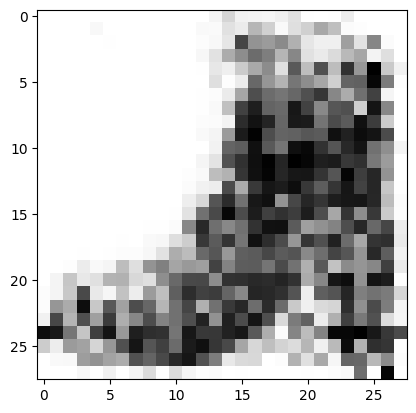

In [ ]:
from keras.models import load_model
from numpy import asarray
from matplotlib import pyplot
from numpy.random import randn

model = load_model('generator_model_final.h5')

vector = randn(100)
vector = vector.reshape(1, 100)

# сгенеруем изображение
X = model.predict(vector)

# Выведем результат
pyplot.imshow(X[0, :, :, 0], cmap='gray_r')
pyplot.show()

In [ ]:
from keras.models import load_model
from numpy.random import randn
from matplotlib import pyplot as plt

In [ ]:

def generate_latent_points(latent_dim, n_samples):
  # генерируем случайные вектора по количеству n_samples
	x_input = randn(latent_dim * n_samples)

	x_input = x_input.reshape(n_samples, latent_dim)
	return x_input

In [ ]:
def save_plot(examples, n):
	for i in range(n * n):
		plt.subplot(n, n, 1 + i)
		plt.axis('off')
		plt.imshow(examples[i, :, :, 0], cmap='gray_r')
	plt.show()

1/1 [==============================] - 0s 178ms/step


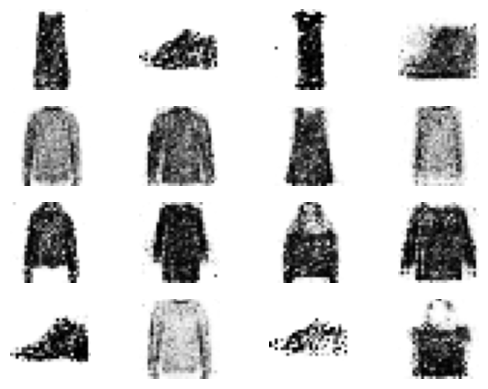

In [ ]:
model = load_model('generator_model_final.h5')

latent_points = generate_latent_points(100, 16)

X = model.predict(latent_points)

save_plot(X, 4)

# **Задание №2.** Обучите генератор воспризводить примитивные изображения по заданному условию (Conditional Generative Adversarial Nets (CGAN)).

(На вход генератора подается вектор случайного шума и метка класса - на выходе должно получиться изображение, соответствующее данному классу)

Датасет выберите по желанию. ([Пример №1](https://www.kaggle.com/datasets/andrewmvd/medical-mnist), [Пример №2](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data#example), [Пример №3](https://www.kaggle.com/datasets/sagyamthapa/handwritten-math-symbols))

In [ ]:
from numpy import zeros
from numpy import ones
from numpy.random import randn
from numpy.random import randint
from keras.optimizers import Adam
from keras.models import Model
from keras.layers import Input
from keras.layers import Dense
from keras.layers import Reshape
from keras.layers import Flatten
from keras.layers import Conv2D
from keras.layers import Conv2DTranspose
from keras.layers import LeakyReLU
from keras.layers import Dropout
from keras.layers import Embedding
from keras.layers import Concatenate

from matplotlib import pyplot as plt

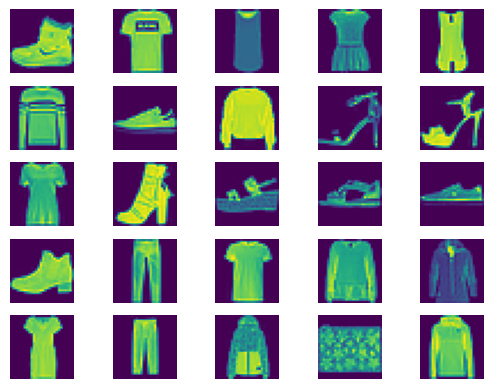

(60000, 28, 28, 1)

In [ ]:

(trainX, trainy), (testX, testy) = fashion_mnist.load_data()
trainX = trainX.reshape(-1, 28, 28, 1)
testX = testX.reshape(-1, 28, 28, 1)
# plot 25 images
for i in range(25):
	plt.subplot(5, 5, 1 + i)
	plt.axis('off')
	plt.imshow(trainX[i])
plt.show()
trainX.shape

In [ ]:
def define_discriminator(in_shape=(28,28,1), n_classes=10):

	in_label = Input(shape=(1,))

	li = Embedding(n_classes, 50)(in_label)

	n_nodes = in_shape[0] * in_shape[1]
	li = Dense(n_nodes)(li)

	li = Reshape((in_shape[0], in_shape[1], 1))(li)

	in_image = Input(shape=in_shape)

	merge = Concatenate()([in_image, li])

	fe = Conv2D(128, (3,3), strides=(2,2), padding='same')(merge)
	fe = LeakyReLU(alpha=0.2)(fe)

	fe = Conv2D(128, (3,3), strides=(2,2), padding='same')(fe)
	fe = LeakyReLU(alpha=0.2)(fe)

	fe = Flatten()(fe)

	fe = Dropout(0.4)(fe)

	out_layer = Dense(1, activation='sigmoid')(fe)

	model = Model([in_image, in_label], out_layer)

	opt = Adam(learning_rate=0.0002, beta_1=0.5)
	model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
	return model

In [ ]:
def define_generator(latent_dim, n_classes=10):

	in_label = Input(shape=(1,))

	li = Embedding(n_classes, 50)(in_label)

	n_nodes = 7 * 7
	li = Dense(n_nodes)(li)

	li = Reshape((7, 7, 1))(li)

	in_lat = Input(shape=(latent_dim,))

	n_nodes = 128 * 7 * 7
	gen = Dense(n_nodes)(in_lat)
	gen = LeakyReLU(alpha=0.2)(gen)
	gen = Reshape((7, 7, 128))(gen)

	merge = Concatenate()([gen, li])

	gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(merge)
	gen = LeakyReLU(alpha=0.2)(gen)

	gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(gen)
	gen = LeakyReLU(alpha=0.2)(gen)

	out_layer = Conv2D(1, (7,7), activation='tanh', padding='same')(gen)

	model = Model([in_lat, in_label], out_layer)
	return model

In [ ]:
def define_gan(g_model, d_model):

	d_model.trainable = False

	gen_noise, gen_label = g_model.input

	gen_output = g_model.output

	gan_output = d_model([gen_output, gen_label])

	model = Model([gen_noise, gen_label], gan_output)

	opt = Adam(learning_rate=0.0002, beta_1=0.5)
	model.compile(loss='binary_crossentropy', optimizer=opt)
	return model

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from keras.datasets.fashion_mnist import load_data
from numpy import expand_dims

def load_real_samples():
	(trainX, trainy), (_, _) = load_data()

	X = expand_dims(trainX, axis=-1)
	X = X.astype('float32')
	X = (X - 127.5) / 127.5
	return [X, trainy]

def generate_real_samples(dataset, n_samples):
	images, labels = dataset
	ix = randint(0, images.shape[0], n_samples)
	X, labels = images[ix], labels[ix]
	y = ones((n_samples, 1))
	return [X, labels], y

In [ ]:
def generate_fake_samples(generator, latent_dim, n_samples):
	z_input, labels_input = generate_latent_points(latent_dim, n_samples)
	images = generator.predict([z_input, labels_input])
	y = zeros((n_samples, 1))
	return [images, labels_input], y

In [ ]:
def generate_latent_points(latent_dim, n_samples, n_classes=10):
	x_input = randn(latent_dim * n_samples)
	z_input = x_input.reshape(n_samples, latent_dim)
	labels = randint(0, n_classes, n_samples)
	return [z_input, labels]

In [ ]:
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=100, n_batch=128):
	bat_per_epo = int(dataset[0].shape[0] / n_batch)
	half_batch = int(n_batch / 2)
	for i in range(n_epochs):
		for j in range(bat_per_epo):
			[X_real, labels_real], y_real = generate_real_samples(dataset, half_batch)
			d_loss1, _ = d_model.train_on_batch([X_real, labels_real], y_real)
			[X_fake, labels], y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
			d_loss2, _ = d_model.train_on_batch([X_fake, labels], y_fake)
			[z_input, labels_input] = generate_latent_points(latent_dim, n_batch)
			y_gan = ones((n_batch, 1))
			g_loss = gan_model.train_on_batch([z_input, labels_input], y_gan)
			print('>%d, %d/%d, d1=%.3f, d2=%.3f g=%.3f' %
				(i+1, j+1, bat_per_epo, d_loss1, d_loss2, g_loss))

In [ ]:
trainX.shape

(60000, 28, 28)

In [ ]:
latent_dim = 100

d_model = define_discriminator()

g_model = define_generator(latent_dim)

gan_model = define_gan(g_model, d_model)

dataset = load_real_samples()

train(g_model, d_model, gan_model, dataset, latent_dim)
g_model.save('cgan_generator.h5')

Выходные данные были обрезаны до нескольких последних строк (5000).
2/2 [==============================] - 0s 5ms/step
>89, 411/468, d1=0.705, d2=0.679 g=1.082
2/2 [==============================] - 0s 5ms/step
>89, 412/468, d1=0.683, d2=0.732 g=1.023
2/2 [==============================] - 0s 5ms/step
>89, 413/468, d1=0.680, d2=0.673 g=1.058
2/2 [==============================] - 0s 4ms/step
>89, 414/468, d1=0.819, d2=0.653 g=0.947
2/2 [==============================] - 0s 5ms/step
>89, 415/468, d1=0.787, d2=0.619 g=1.018
2/2 [==============================] - 0s 5ms/step
>89, 416/468, d1=0.671, d2=0.603 g=0.925
2/2 [==============================] - 0s 4ms/step
>89, 417/468, d1=0.667, d2=0.686 g=1.003
2/2 [==============================] - 0s 5ms/step
>89, 418/468, d1=0.655, d2=0.613 g=0.995
2/2 [==============================] - 0s 5ms/step
>89, 419/468, d1=0.665, d2=0.627 g=0.919
2/2 [==============================] - 0s 4ms/step
>89, 420/468, d1=0.696, d2=0.732 g=0.940
2/2 [=======

### Демонстрация сгенерированных изображений:

In [ ]:
from numpy import asarray
from numpy.random import randn
from numpy.random import randint
from keras.models import load_model
import numpy as np

In [ ]:
model = load_model('/content/cgan_generator.h5')

4/4 [==============================] - 1s 110ms/step


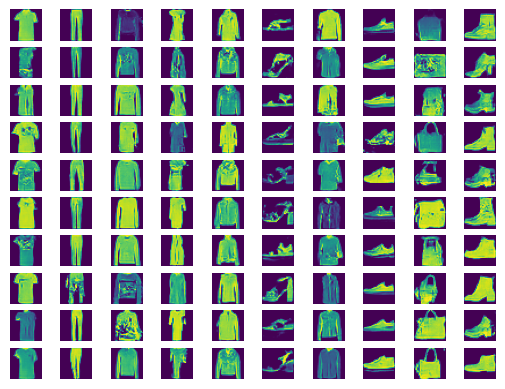

In [ ]:
# генерируем набор случайных векторов и меток классов
latent_points, labels = generate_latent_points(100, 100)

# задаём метки классов - генерируем 10 наборов меток,
# каждая из которых имеет значение от 0 до 9
labels = asarray([x for _ in range(10) for x in range(10)])

X  = model.predict([latent_points, labels])

# Преобразуем значения каждого пикселя в диапазон [0, 255] из диапазона [-1,1]
X = (X + 1) / 2.0
X = (X*255).astype(np.uint8)

def show_plot(examples, n):
	for i in range(n * n):
		plt.subplot(n, n, 1 + i)
		plt.axis('off')
		plt.imshow(examples[i, :, :, :])
	plt.savefig('fashion_mnist_generate.png', dpi = 300)
	plt.show()

show_plot(X, 10)

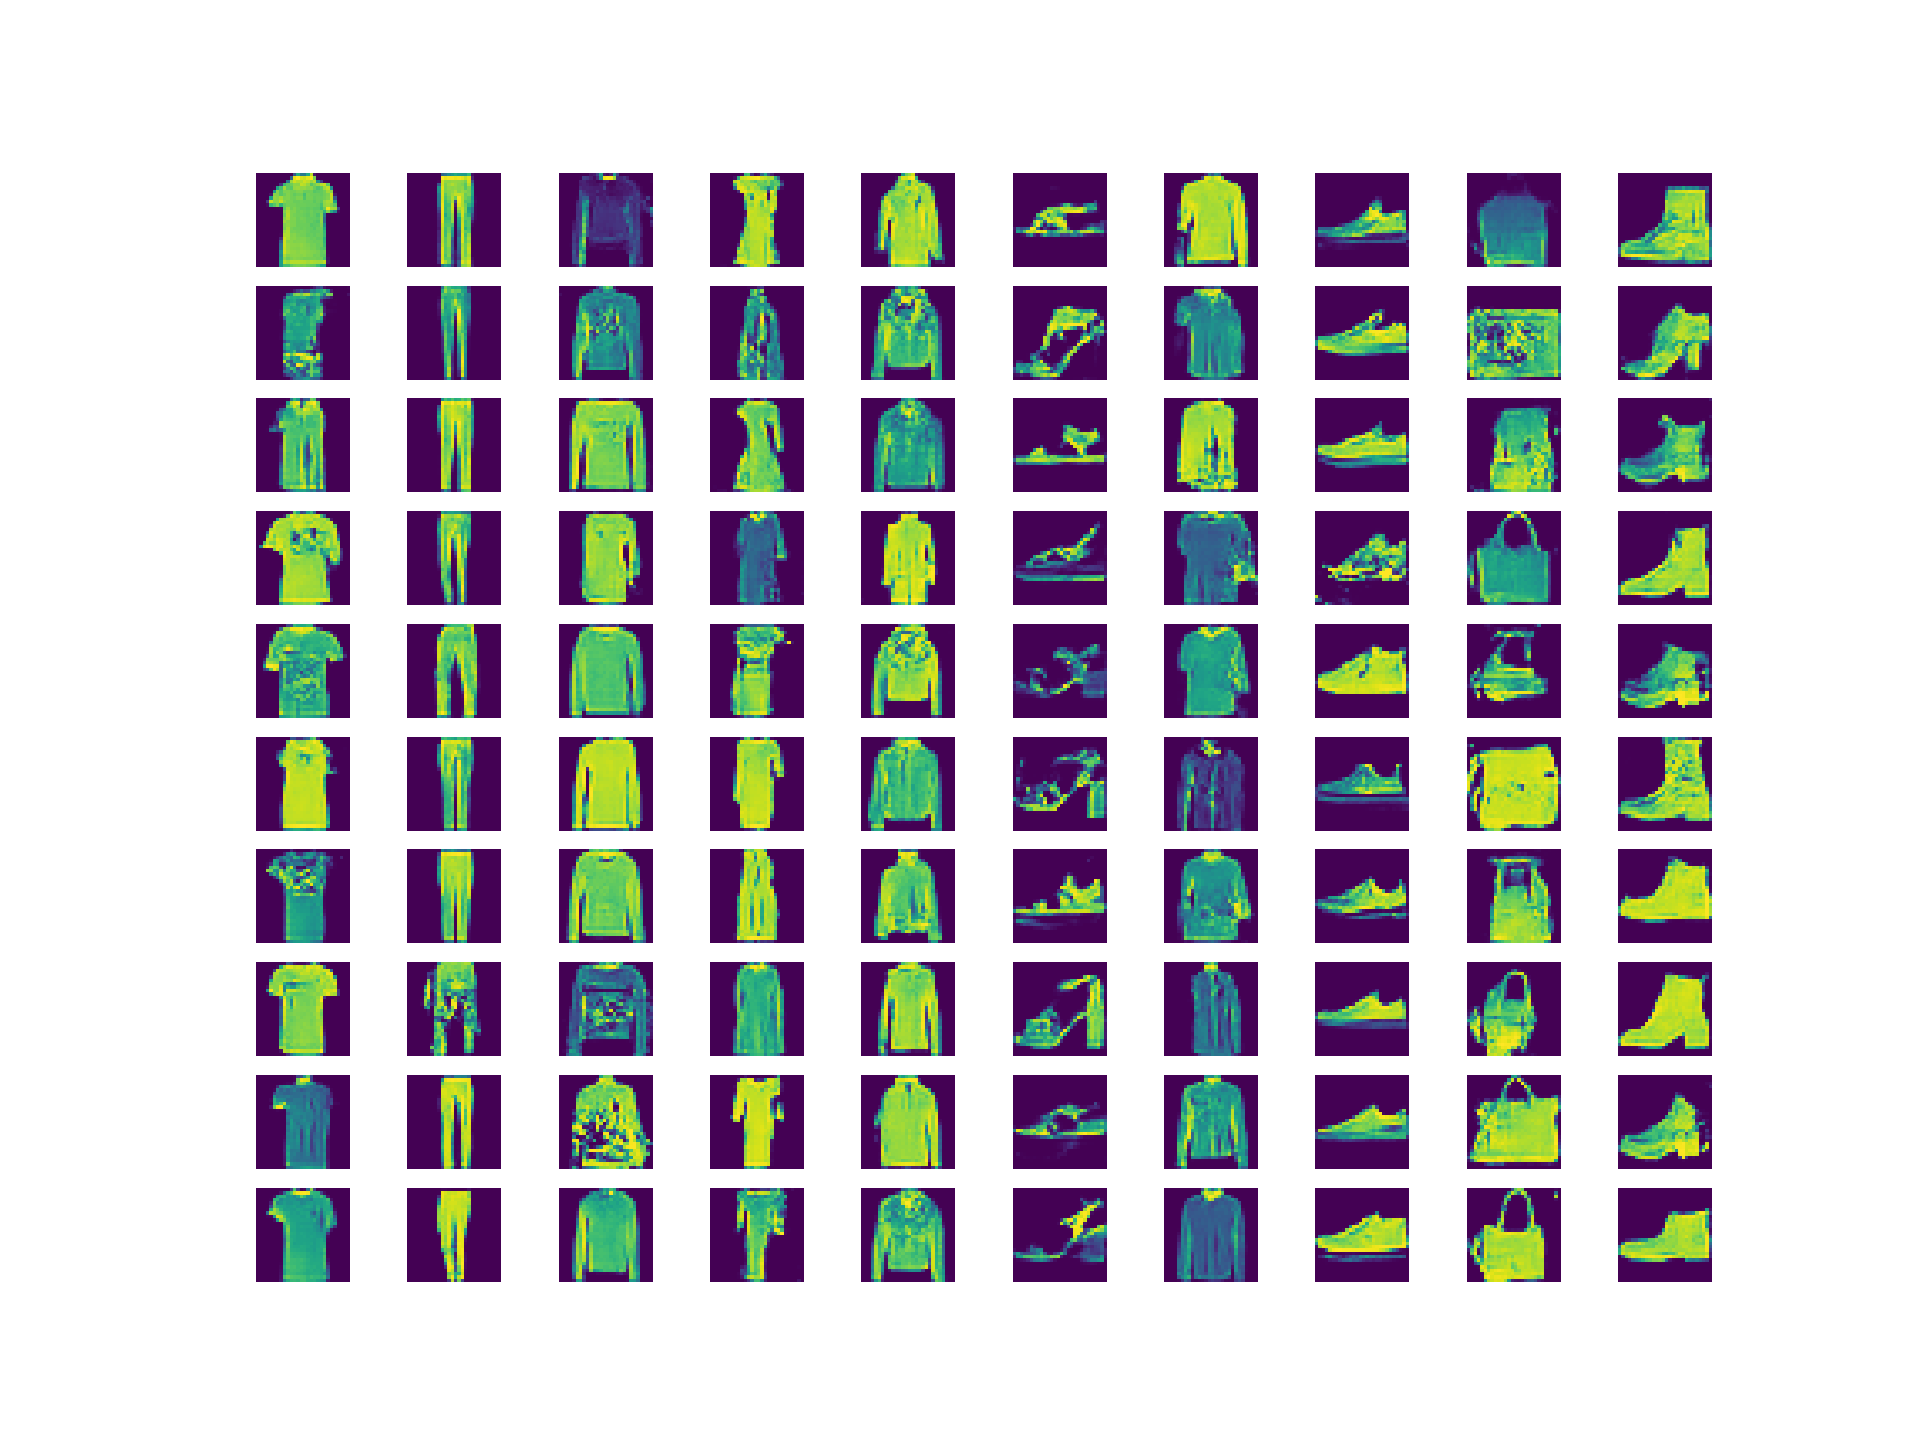

In [ ]:
from IPython.display import Image
Image('/content/fashion_mnist_generate.png')

# **Задание №3.** Обучите генератор воспризводить **спутниковый снимок** по **загруженной маске** (pix2pix). Используйте для этого разделенный на патчи  [датасет](https://www.kaggle.com/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery)

In [ ]:
from numpy import zeros
from numpy import ones
from numpy.random import randint
from keras.optimizers import Adam
from keras.initializers import RandomNormal
from keras.models import Model
from keras import Input
from keras.layers import Conv2D
from keras.layers import Conv2DTranspose
from keras.layers import LeakyReLU
from keras.layers import Activation
from keras.layers import Concatenate
from keras.layers import Dropout
from keras.layers import BatchNormalization
from matplotlib import pyplot as plt
from tensorflow.keras.utils import plot_model

In [ ]:
def define_discriminator(image_shape):

	# инициализация веса
	init = RandomNormal(stddev=0.02) # Как описано в оригинальной статье

	# Входной слой для исходного изображения
	in_src_image = Input(shape=image_shape)  # Изображение, которое мы хотим преобразовать в другое изображение
  # Входной слой для целевого изображения
	in_target_image = Input(shape=image_shape)  # Изображение, которое мы хотим получить после обучения.

  # конкатенируем изображения по каналам
	merged = Concatenate()([in_src_image, in_target_image])

	# C64: 4x4 kernel Stride 2x2
	d = Conv2D(64, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(merged)
	d = LeakyReLU(alpha=0.2)(d)
	# C128: 4x4 kernel Stride 2x2
	d = Conv2D(128, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# C256: 4x4 kernel Stride 2x2
	d = Conv2D(256, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# C512: 4x4 kernel Stride 2x2. Этот блок кода добавлен самостоятельно, его нет в оригинальной статье. Закомментируйте его, если хотите.
	d = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# последний выходной слой: 4x4 kernel but Stride 1x1
	d = Conv2D(512, (4,4), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# формирование патча
	d = Conv2D(1, (4,4), padding='same', kernel_initializer=init)(d)
	patch_out = Activation('sigmoid')(d)
	# определяем модель
	model = Model([in_src_image, in_target_image], patch_out)

   #Модель обучается с размером партии в одно изображение, оптимизатором Adam с небольшой скоростью обучения и значением beta = 0.5.
    # Устанавливаем весовой коэффициент для дискриминатора в 50% (0.5) .

	opt = Adam(learning_rate=0.0002, beta_1=0.5)
	model.compile(loss='binary_crossentropy', optimizer=opt, loss_weights=[0.5])
	return model

In [ ]:
def define_encoder_block(layer_in, n_filters, batchnorm=True):
	# инициализируем вес
	init = RandomNormal(stddev=0.02)
  # добавим слой понижающей дискретизации
	g = Conv2D(n_filters, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(layer_in)
  # добавим опционально нормализацию батчей
	if batchnorm:
	  g = BatchNormalization()(g, training=True)
	g = LeakyReLU(alpha=0.2)(g)
	return g

In [ ]:
def decoder_block(layer_in, skip_in, n_filters, dropout=True):
	# инициализируем вес
	init = RandomNormal(stddev=0.02)
	# добавим слой повышающей дискретизации
	g = Conv2DTranspose(n_filters, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(layer_in)
	# добавим нормализацию батчей
	g = BatchNormalization()(g, training=True)
	# опционально добавим дропаут
	if dropout:
		g = Dropout(0.5)(g, training=True)
	# объединяем с пропуском соединения (skip connection)
	g = Concatenate()([g, skip_in])
	g = Activation('relu')(g)
	return g

In [ ]:
def define_generator(image_shape=(256,256,3)):
	# инициализация веса
	init = RandomNormal(stddev=0.02)
	# входной слой для изображения
	in_image = Input(shape=image_shape)
	# Архитектура энкодера: C64-C128-C256-C512-C512-C512-C512-C512
	e1 = define_encoder_block(in_image, 64, batchnorm=False)
	e2 = define_encoder_block(e1, 128)
	e3 = define_encoder_block(e2, 256)
	e4 = define_encoder_block(e3, 512)
	e5 = define_encoder_block(e4, 512)
	e6 = define_encoder_block(e5, 512)
	e7 = define_encoder_block(e6, 512)
	b = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(e7)
	b = Activation('relu')(b)
	# Архитектура декодера: CD512-CD512-CD512-C512-C256-C128-C64
	d1 = decoder_block(b, e7, 512)
	d2 = decoder_block(d1, e6, 512)
	d3 = decoder_block(d2, e5, 512)
	d4 = decoder_block(d3, e4, 512, dropout=False)
	d5 = decoder_block(d4, e3, 256, dropout=False)
	d6 = decoder_block(d5, e2, 128, dropout=False)
	d7 = decoder_block(d6, e1, 64, dropout=False)
	# Выходной слой
	g = Conv2DTranspose(image_shape[2], (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d7)
	out_image = Activation('tanh')(g)  #Генерируется изображение в диапазоне от -1 до 1.
	# Определяем модель
	model = Model(in_image, out_image)
	return model

# gen_model = define_generator((256,256,3))
# plot_model(gen_model, to_file='gen_model.png', show_shapes=True)

In [ ]:
# определяем комбинированную модель генератора и дискриминатора, для обновления генератора
def define_gan(g_model, d_model, image_shape):
	# делаем веса в дискриминаторе не обучаемыми
	for layer in d_model.layers:
		if not isinstance(layer, BatchNormalization):
			layer.trainable = False       #Слои дескриминатора установлены на необучаемые в комбинированной GAN, но
                                    # отдельный дескриминатор будет обучаемым.

	# определим входной слой для исходного изображения
	in_src = Input(shape=image_shape)
	# подаём изображение на вход генератора
	gen_out = g_model(in_src)
	# подаём входное изображения и сформированного изображения в качестве входных данных в дискриминатор
	dis_out = d_model([in_src, gen_out])
	# входное изображение в качестве входа, сгенерированное изображение и значение выходного слоя дискриминатора в качестве выходов
	model = Model(in_src, [dis_out, gen_out])
	opt = Adam(learning_rate=0.0002, beta_1=0.5)

  #Общая потеря - это взвешенная сумма потерь от “состязательности” (Бинарная кросс-энтропия) и потери от MAE (L1).
  #Авторы предложили взвесить соотношение BCE и MAE как 1:100.
	model.compile(loss=['binary_crossentropy', 'mae'],
               optimizer=opt, loss_weights=[1,100])
	return model

In [ ]:
def generate_real_samples(dataset, n_samples, patch_shape):
	# распаковка набора данных
	trainA, trainB = dataset
	# выбор случайных экземпляры
	ix = randint(0, trainA.shape[0], n_samples)
	# извлечение выбранных изображений
	X1, X2 = trainA[ix], trainB[ix]
	# генерация "реальных" меток классов (1)
	y = ones((n_samples, patch_shape, patch_shape, 1))
	return [X1, X2], y

In [ ]:
def generate_fake_samples(g_model, samples, patch_shape):
	X = g_model.predict(samples)
	# генерация "поддельных" меток классов (0)
	y = zeros((len(X), patch_shape, patch_shape, 1))
	return X, y

In [ ]:
def summarize_performance(step, g_model, dataset, n_samples=3):
	# формирование выборки входных изображений
	[X_realA, X_realB], _ = generate_real_samples(dataset, n_samples, 1)
	# генерация партии поддельных изображений
	X_fakeB, _ = generate_fake_samples(g_model, X_realA, 1)
	# Нормализация
	X_realA = (X_realA + 1) / 2.0
	X_realB = (X_realB + 1) / 2.0
	X_fakeB = (X_fakeB + 1) / 2.0

	for i in range(n_samples):
		plt.subplot(3, n_samples, 1 + i)
		plt.axis('off')
		plt.imshow(X_realA[i])

	for i in range(n_samples):
		plt.subplot(3, n_samples, 1 + n_samples + i)
		plt.axis('off')
		plt.imshow(X_fakeB[i])

	for i in range(n_samples):
		plt.subplot(3, n_samples, 1 + n_samples*2 + i)
		plt.axis('off')
		plt.imshow(X_realB[i])

	filename1 = 'plot_%06d.png' % (step+1)
	plt.savefig(filename1)
	plt.close()

	filename2 = 'model_%06d.h5' % (step+1)
	g_model.save(filename2)
	print('>Saved: %s and %s' % (filename1, filename2))

In [ ]:
def train(d_model, g_model, gan_model, dataset, n_epochs=100, n_batch=1):
	# определение размерности выходного значения дискриминатора
	n_patch = d_model.output_shape[1]
	# распаковка датасета
	trainA, trainB = dataset
	# вычисление количества партий на одну эпоху обучения
	bat_per_epo = int(len(trainA) / n_batch)
	# вычисление количества тренировочных итераций
	n_steps = bat_per_epo * n_epochs
	for i in range(n_steps):
 		# формирование партии обучающей выборки (реальных образцов)
		[X_realA, X_realB], y_real = generate_real_samples(dataset, n_batch, n_patch)
		# генерация партии поддельных образцов
		X_fakeB, y_fake = generate_fake_samples(g_model, X_realA, n_patch)
		# обучение дискриминатора на реальных образцах
		d_loss1 = d_model.train_on_batch([X_realA, X_realB], y_real)
		# обучение дискриминатора на «поддельных» образцах
		d_loss2 = d_model.train_on_batch([X_realA, X_fakeB], y_fake)
		# обучение генератора
		g_loss, _, _ = gan_model.train_on_batch(X_realA, [y_real, X_realB])
		# индикация процесса обучения
		print(f'Эпоха: {((i+1) // bat_per_epo) + 1}')
		print('Итерация: %d, d1[%.3f] d2[%.3f] g[%.3f]' % (i+1, d_loss1, d_loss2, g_loss))
		if (i+1) % (bat_per_epo * 1) == 0: # Сохраняем модель генератора и набор изображений каждую (1) эпоху.
			summarize_performance(i, g_model, dataset)

In [ ]:
import os
from os import listdir
from numpy import asarray, load
from numpy import vstack
from keras.utils import img_to_array
from keras.utils import load_img
from numpy import savez_compressed
from matplotlib import pyplot
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def load_images(path, size=(256,256)):
  src_list, tar_list = list(), list()
  suffix=".jpg"
  for path, subdirs, files in os.walk(path):
    if len(subdirs) == 0:
      files.sort()
      for file in files:
        if file.endswith(suffix):
          pixels = load_img(path + "/" + file, target_size=size)
          src_list.append(img_to_array(pixels))
        else :
          pixels = load_img(path + "/" + file.replace(suffix, ".png"), target_size=size)
          tar_list.append(img_to_array(pixels))
  return [asarray(tar_list), asarray(src_list)]

In [ ]:
import os
datadir = 'segmentation'
if os.path.isdir(datadir)>0:
    print ('Data directory already exists and it is not empty, miss downloading')
else:
    print ('Data directory does not exists or it is empty, download the dataset')
    !gdown --id 1jZSged2UT_mfHhjp_s4DlhyNLb_Tpm0r
    !unzip segmentation.zip

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
path = "/content/drive/MyDrive/segmentation"
[src_images, tar_images] = load_images(path)
print('Загружено: ', src_images.shape, tar_images.shape)

Загружено:  (72, 256, 256, 3) (72, 256, 256, 3)


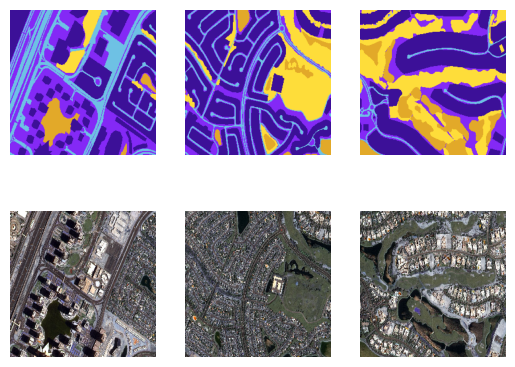

In [ ]:
n_samples = 3
for i in range(n_samples):
	pyplot.subplot(2, n_samples, 1 + i)
	pyplot.axis('off')
	pyplot.imshow(src_images[i].astype('uint8'))

for i in range(n_samples):
	pyplot.subplot(2, n_samples, 1 + n_samples + i)
	pyplot.axis('off')
	pyplot.imshow(tar_images[i].astype('uint8'))
pyplot.show()

In [ ]:
def preprocess_data(data):
	X1, X2 = data[0], data[1]
	X1 = (X1 - 127.5) / 127.5
	X2 = (X2 - 127.5) / 127.5
	return [X1, X2]

dataset = preprocess_data([src_images, tar_images]) # Предобработка исходного датасета

In [ ]:
image_shape = src_images.shape[1:] # определяем размерность входного слоя на основе загруженного набора данных

# определяем модели
d_model = define_discriminator(image_shape)
g_model = define_generator(image_shape)
gan_model = define_gan(g_model, d_model, image_shape)

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [ ]:
from datetime import datetime
n_epochs = 100
start1 = datetime.now()
train(d_model, g_model, gan_model, dataset, n_epochs=n_epochs, n_batch=1)
stop1 = datetime.now()

execution_time = stop1-start1
print("Время обучения модели: ", execution_time, f"(\nОдна эпоха: {(execution_time/n_epochs).total_seconds()/60} минут)")

1/1 [==============================] - 0s 29ms/step
Эпоха: 1
Итерация: 1, d1[0.314] d2[2.001] g[63.984]
1/1 [==============================] - 0s 19ms/step
Эпоха: 1
Итерация: 2, d1[1.327] d2[1.228] g[47.059]
1/1 [==============================] - 0s 23ms/step
Эпоха: 1
Итерация: 3, d1[1.645] d2[1.177] g[46.007]
1/1 [==============================] - 0s 20ms/step
Эпоха: 1
Итерация: 4, d1[0.900] d2[0.647] g[33.130]
1/1 [==============================] - 0s 38ms/step
Эпоха: 1
Итерация: 5, d1[0.597] d2[0.555] g[45.235]
1/1 [==============================] - 0s 18ms/step
Эпоха: 1
Итерация: 6, d1[0.469] d2[0.830] g[50.675]
1/1 [==============================] - 0s 18ms/step
Эпоха: 1
Итерация: 7, d1[0.637] d2[0.457] g[55.021]
1/1 [==============================] - 0s 19ms/step
Эпоха: 1
Итерация: 8, d1[0.482] d2[0.427] g[40.103]
1/1 [==============================] - 0s 19ms/step
Эпоха: 1
Итерация: 9, d1[0.485] d2[0.494] g[53.068]
1/1 [==============================] - 0s 22ms/step
Эпоха: 1
Ите

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


>Saved: plot_000072.png and model_000072.h5
1/1 [==============================] - 0s 22ms/step
Эпоха: 2
Итерация: 73, d1[0.413] d2[0.573] g[9.376]
1/1 [==============================] - 0s 24ms/step
Эпоха: 2
Итерация: 74, d1[0.457] d2[0.442] g[26.276]
1/1 [==============================] - 0s 19ms/step
Эпоха: 2
Итерация: 75, d1[0.429] d2[0.432] g[23.985]
1/1 [==============================] - 0s 19ms/step
Эпоха: 2
Итерация: 76, d1[0.525] d2[0.552] g[15.887]
1/1 [==============================] - 0s 21ms/step
Эпоха: 2
Итерация: 77, d1[0.389] d2[0.447] g[27.150]
1/1 [==============================] - 0s 19ms/step
Эпоха: 2
Итерация: 78, d1[0.441] d2[0.435] g[29.305]
1/1 [==============================] - 0s 19ms/step
Эпоха: 2
Итерация: 79, d1[0.421] d2[0.419] g[27.215]
1/1 [==============================] - 0s 19ms/step


KeyboardInterrupt: 

### Демонстрация сгенерированных изображений:

In [ ]:
from keras.models import load_model
from numpy.random import randint

model = load_model('/content/model_007200.h5')

In [ ]:
def plot_images(src_img, gen_img, tar_img):
	images = vstack((src_img, gen_img, tar_img))
	images = (images + 1) / 2.0
	titles = ['Исходное', 'Сгенерированное', 'Ожидаемое']
	for i in range(len(images)):
		pyplot.subplot(1, 3, 1 + i)
		pyplot.axis('off')
		pyplot.imshow(images[i])
		pyplot.title(titles[i])
	pyplot.show()

1/1 [==============================] - 0s 368ms/step


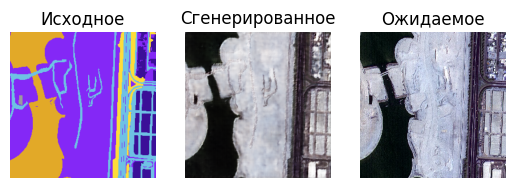

1/1 [==============================] - 0s 20ms/step


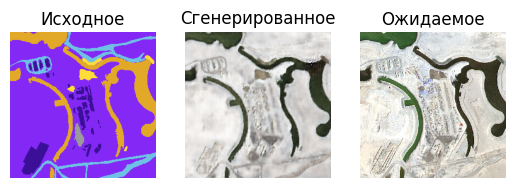

1/1 [==============================] - 0s 22ms/step


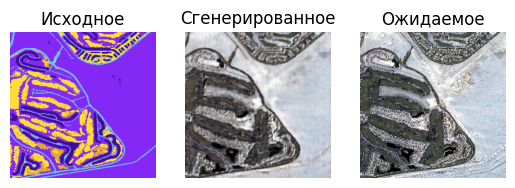

1/1 [==============================] - 0s 20ms/step


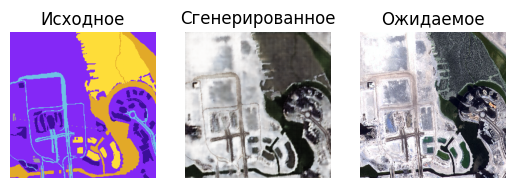

1/1 [==============================] - 0s 25ms/step


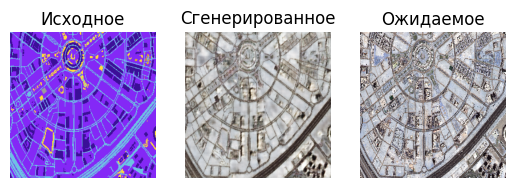

1/1 [==============================] - 0s 22ms/step


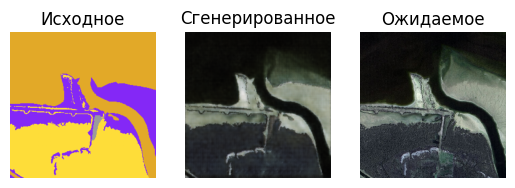

1/1 [==============================] - 0s 20ms/step


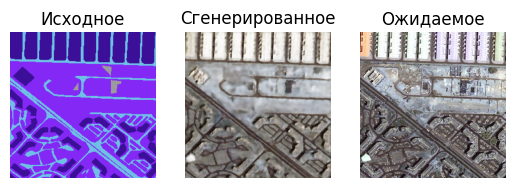

1/1 [==============================] - 0s 19ms/step


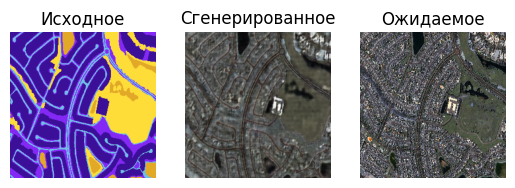

1/1 [==============================] - 0s 23ms/step


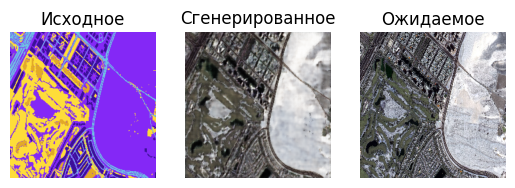

1/1 [==============================] - 0s 20ms/step


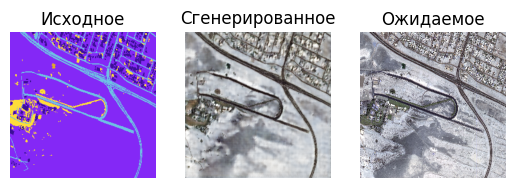

In [ ]:
from numpy.random import randint
[X1, X2] = dataset

for i in range(10):
  ix = randint(0, len(X1), 1) # выбираем случайные изображения
  src_image, tar_image = X1[ix], X2[ix]
  gen_image = model.predict(src_image) # генерируем целевое изображение (карту)
  plot_images(src_image, gen_image, tar_image) # Выводим оригинальное изображение, оригинальную карту и сгенерированную карту

# **Задание №4.** Обучите генератор воспроизводить изображения из выбранного Вами датасета (pix2pix).

### Датасет может быть сформирован Вами (например, черно-белые и цветные изображения) или найден в глобальной сети Интернет.

#### Например [тут](https://www.kaggle.com/search?q=pix2pix+in%3Adatasets+datasetFileTypes%3Ajpg+datasetFileTypes%3Apng) или [тут](http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/)

In [ ]:
from numpy import zeros
from numpy import ones
from numpy.random import randint
from keras.optimizers import Adam
from keras.initializers import RandomNormal
from keras.models import Model
from keras import Input
from keras.layers import Conv2D
from keras.layers import Conv2DTranspose
from keras.layers import LeakyReLU
from keras.layers import Activation
from keras.layers import Concatenate
from keras.layers import Dropout
from keras.layers import BatchNormalization
from matplotlib import pyplot as plt
from keras.utils import plot_model
import os
from os import listdir
from numpy import asarray, load
from numpy import vstack
from keras.utils import img_to_array
from keras.utils import load_img
from numpy import savez_compressed
from matplotlib import pyplot
import numpy as np
from os import listdir
from os.path import isfile, join

In [ ]:
def define_discriminator(image_shape):

	# инициализация веса
	init = RandomNormal(stddev=0.02)

	# Входной слой для исходного изображения
	in_src_image = Input(shape=image_shape)
  # Входной слой для целевого изображения
	in_target_image = Input(shape=image_shape)

  # конкатенируем изображения по каналам
	merged = Concatenate()([in_src_image, in_target_image])

	# C64: 4x4 kernel Stride 2x2
	d = Conv2D(64, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(merged)
	d = LeakyReLU(alpha=0.2)(d)
	# C128: 4x4 kernel Stride 2x2
	d = Conv2D(128, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# C256: 4x4 kernel Stride 2x2
	d = Conv2D(256, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# C512: 4x4 kernel Stride 2x2.
	d = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# последний выходной слой: 4x4 kernel but Stride 1x1
	d = Conv2D(512, (4,4), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# формирование патча
	d = Conv2D(1, (4,4), padding='same', kernel_initializer=init)(d)
	patch_out = Activation('sigmoid')(d)
	# определяем модель
	model = Model([in_src_image, in_target_image], patch_out)

	opt = Adam(learning_rate=0.0002, beta_1=0.5)
	model.compile(loss='binary_crossentropy', optimizer=opt, loss_weights=[0.5])
	return model

In [ ]:
def define_encoder_block(layer_in, n_filters, batchnorm=True):
	init = RandomNormal(stddev=0.02)
	g = Conv2D(n_filters, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(layer_in)
	if batchnorm:
	  g = BatchNormalization()(g, training=True)
	g = LeakyReLU(alpha=0.2)(g)
	return g

In [ ]:
def decoder_block(layer_in, skip_in, n_filters, dropout=True):
	init = RandomNormal(stddev=0.02)
	g = Conv2DTranspose(n_filters, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(layer_in)
	g = BatchNormalization()(g, training=True)
	if dropout:
		g = Dropout(0.5)(g, training=True)
	g = Concatenate()([g, skip_in])
	g = Activation('relu')(g)
	return g

In [ ]:
def define_generator(image_shape=(256,256,3)):

	init = RandomNormal(stddev=0.02)

	in_image = Input(shape=image_shape)

	e1 = define_encoder_block(in_image, 64, batchnorm=False)
	e2 = define_encoder_block(e1, 128)
	e3 = define_encoder_block(e2, 256)
	e4 = define_encoder_block(e3, 512)
	e5 = define_encoder_block(e4, 512)
	e6 = define_encoder_block(e5, 512)
	e7 = define_encoder_block(e6, 512)
	b = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(e7)
	b = Activation('relu')(b)

	d1 = decoder_block(b, e7, 512)
	d2 = decoder_block(d1, e6, 512)
	d3 = decoder_block(d2, e5, 512)
	d4 = decoder_block(d3, e4, 512, dropout=False)
	d5 = decoder_block(d4, e3, 256, dropout=False)
	d6 = decoder_block(d5, e2, 128, dropout=False)
	d7 = decoder_block(d6, e1, 64, dropout=False)

	g = Conv2DTranspose(image_shape[2], (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d7)
	out_image = Activation('tanh')(g)

	model = Model(in_image, out_image)
	return model

In [ ]:
def define_gan(g_model, d_model, image_shape):
	for layer in d_model.layers:
		if not isinstance(layer, BatchNormalization):
			layer.trainable = False       #Слои дескриминатора установлены на необучаемые в комбинированной GAN, но
                                    # отдельный дескриминатор будет обучаемым.

	in_src = Input(shape=image_shape)
	gen_out = g_model(in_src)
	dis_out = d_model([in_src, gen_out])
	model = Model(in_src, [dis_out, gen_out])
	opt = Adam(learning_rate=0.0002, beta_1=0.5)

	model.compile(loss=['binary_crossentropy', 'mae'],
               optimizer=opt, loss_weights=[1,100])
	return model

In [ ]:
def generate_real_samples(dataset, n_samples, patch_shape):
	trainA, trainB = dataset
	ix = randint(0, trainA.shape[0], n_samples)
	X1, X2 = trainA[ix], trainB[ix]
	y = ones((n_samples, patch_shape, patch_shape, 1))
	return [X1, X2], y

In [ ]:
def generate_fake_samples(g_model, samples, patch_shape):
	X = g_model.predict(samples)
	y = zeros((len(X), patch_shape, patch_shape, 1))
	return X, y

In [ ]:
def summarize_performance(step, g_model, dataset, n_samples=3):
	[X_realA, X_realB], _ = generate_real_samples(dataset, n_samples, 1)

	X_fakeB, _ = generate_fake_samples(g_model, X_realA, 1)

	X_realA = (X_realA + 1) / 2.0
	X_realB = (X_realB + 1) / 2.0
	X_fakeB = (X_fakeB + 1) / 2.0

	for i in range(n_samples):
		plt.subplot(3, n_samples, 1 + i)
		plt.axis('off')
		plt.imshow(X_realA[i])

	for i in range(n_samples):
		plt.subplot(3, n_samples, 1 + n_samples + i)
		plt.axis('off')
		plt.imshow(X_fakeB[i])

	for i in range(n_samples):
		plt.subplot(3, n_samples, 1 + n_samples*2 + i)
		plt.axis('off')
		plt.imshow(X_realB[i])

	filename1 = 'plot_%06d.png' % (step+1)
	plt.savefig(filename1)
	plt.close()

	filename2 = 'model_%06d.h5' % (step+1)
	g_model.save(os.path.join("/content/", filename2))
	print('>Saved: %s and %s' % (filename1, filename2))

In [ ]:
def train(d_model, g_model, gan_model, dataset, n_epochs=100, n_batch=1):
	n_patch = d_model.output_shape[1]

	trainA, trainB = dataset

	bat_per_epo = int(len(trainA) / n_batch)

	n_steps = bat_per_epo * n_epochs
	for i in range(n_steps):

		[X_realA, X_realB], y_real = generate_real_samples(dataset, n_batch, n_patch)

		X_fakeB, y_fake = generate_fake_samples(g_model, X_realA, n_patch)

		d_loss1 = d_model.train_on_batch([X_realA, X_realB], y_real)

		d_loss2 = d_model.train_on_batch([X_realA, X_fakeB], y_fake)

		g_loss, _, _ = gan_model.train_on_batch(X_realA, [y_real, X_realB])

		print(f'Эпоха: {((i+1) // bat_per_epo) + 1}')
		print('Итерация: %d, d1[%.3f] d2[%.3f] g[%.3f]' % (i+1, d_loss1, d_loss2, g_loss))
		if (i+1) % (bat_per_epo * 1) == 0:
			summarize_performance(i, g_model, dataset)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def load_images(path, size=(256,256)):
  src_list, tar_list = list(), list()
  files = [f for f in listdir(os.path.join(path, "face")) if isfile(join(os.path.join(path, "face"), f))]
  for i in range(10):
    pixels = load_img(os.path.join(path, "face", files[i]), target_size=size)
    src_list.append(img_to_array(pixels))
    pixels = load_img(os.path.join(path, "comics", files[i]), target_size=size)
    tar_list.append(img_to_array(pixels))
  return [asarray(src_list), asarray(tar_list)]

In [ ]:
path = "/content/drive/MyDrive/face2comics"
train_img_gen = load_images(path)
[src_images, tar_images] = load_images(path)
print('Загружено: ', src_images.shape, tar_images.shape)

Загружено:  (10, 256, 256, 3) (10, 256, 256, 3)


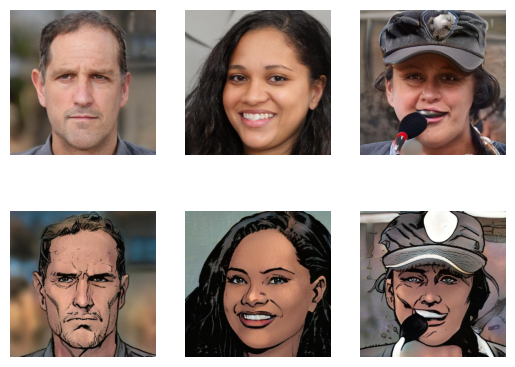

In [ ]:
n_samples = 3

for i in range(n_samples):
	pyplot.subplot(2, n_samples, 1 + i)
	pyplot.axis('off')
	pyplot.imshow(src_images[i].astype('uint8'))

for i in range(n_samples):
	pyplot.subplot(2, n_samples, 1 + n_samples + i)
	pyplot.axis('off')
	pyplot.imshow(tar_images[i].astype('uint8'))
pyplot.show()

In [ ]:
def preprocess_data(data):
	X1, X2 = data[0], data[1]
	X1 = (X1 - 127.5) / 127.5
	X2 = (X2 - 127.5) / 127.5
	return [X1, X2]
dataset = preprocess_data([src_images, tar_images]) # Предобработка исходного датасета

In [ ]:
image_shape = src_images.shape[1:] # определяем размерность входного слоя на основе загруженного набора данных

d_model = define_discriminator(image_shape)
g_model = define_generator(image_shape)
gan_model = define_gan(g_model, d_model, image_shape)

In [ ]:
from datetime import datetime
n_epochs = 100
start1 = datetime.now()
train(d_model, g_model, gan_model, dataset, n_epochs=n_epochs, n_batch=1)
stop1 = datetime.now()

execution_time = stop1-start1
print("Время обучения модели: ", execution_time, f"(\nОдна эпоха: {(execution_time/n_epochs).total_seconds()/60} минут)")

In [ ]:
from keras.models import load_model
from numpy.random import randint

model = load_model('/content/model_001000.h5')

### Демонстрация сгенерированных изображений:

In [ ]:
def plot_images(src_img, gen_img, tar_img):
	images = vstack((src_img, gen_img, tar_img))
	images = (images + 1) / 2.0
	titles = ['Исходное', 'Сгенерированное', 'Ожидаемое']
	for i in range(len(images)):
		pyplot.subplot(1, 3, 1 + i)
		pyplot.axis('off')
		pyplot.imshow(images[i])
		pyplot.title(titles[i])
	pyplot.show()

1/1 [==============================] - 0s 20ms/step


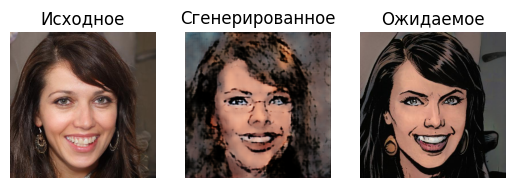

1/1 [==============================] - 0s 21ms/step


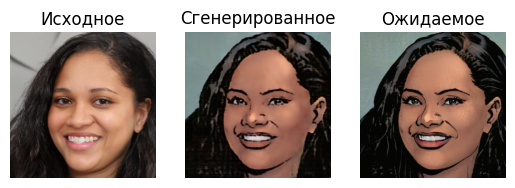

1/1 [==============================] - 0s 19ms/step


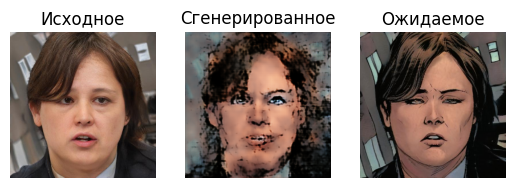

1/1 [==============================] - 0s 19ms/step


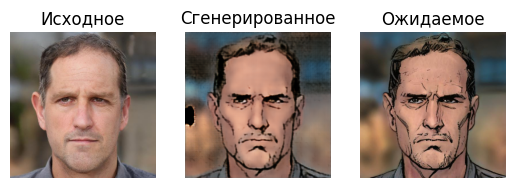

1/1 [==============================] - 0s 19ms/step


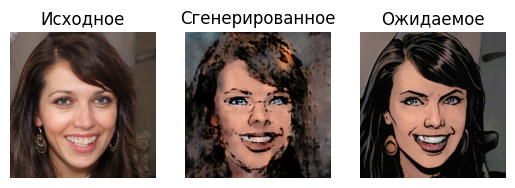

1/1 [==============================] - 0s 18ms/step


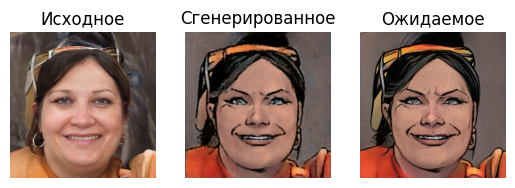

1/1 [==============================] - 0s 32ms/step


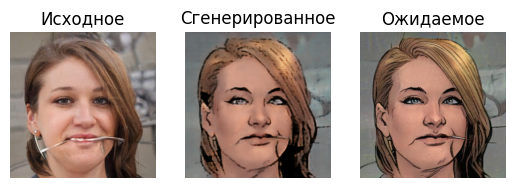

1/1 [==============================] - 0s 78ms/step


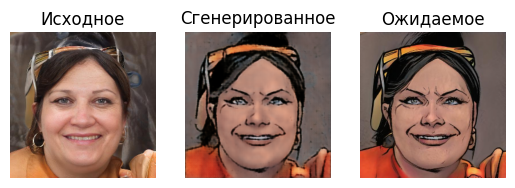

1/1 [==============================] - 0s 50ms/step


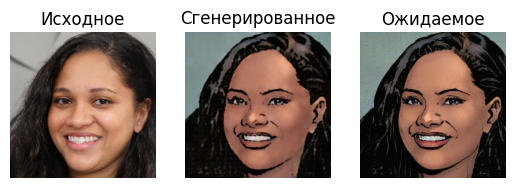

1/1 [==============================] - 0s 21ms/step


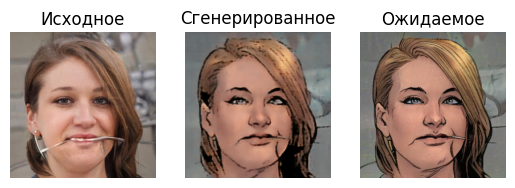

In [ ]:
[X1, X2] = dataset

for i in range(10):
  ix = randint(0, len(X1), 1)
  src_image, tar_image = X1[ix], X2[ix]
  gen_image = model.predict(src_image)
  plot_images(src_image, gen_image, tar_image)